In [8]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from gmdh import Combi, Multi, Mia, Ria

# Загрузка датасета
california = load_diabetes()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

# Просмотр первых строк данных
print("Первые 5 строк датасета:")
print(X.head())
print("\nОписание признаков:")
print(california.DESCR)

Первые 5 строк датасета:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Описание признаков:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progressi

In [9]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (353, 10)
Размер тестовой выборки: (89, 10)


In [10]:
# Определение базовых моделей для стекинга
base_models = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(random_state=42))
]

# Создание и обучение модели стекинга
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)
stacking_model.fit(X_train_scaled, y_train)

# Предсказание и оценка
y_pred_stack = stacking_model.predict(X_test_scaled)
mse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

print("\nStacking Model:")
print(f"MSE: {mse_stack:.4f}")
print(f"R2: {r2_stack:.4f}")


Stacking Model:
MSE: 2841.4955
R2: 0.4637


In [27]:
# Преобразование данных в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Определение архитектуры сети
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Инициализация модели
model = MLP(X_train_scaled.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение модели
epochs = 800
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Оценка модели
with torch.no_grad():
    y_pred_mlp = model(X_test_tensor).numpy()
    mse_mlp = mean_squared_error(y_test, y_pred_mlp)
    r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nMLP Model:")
print(f"MSE: {mse_mlp:.4f}")
print(f"R2: {r2_mlp:.4f}")

Epoch [50/800], Loss: 28846.9414
Epoch [100/800], Loss: 25157.5352
Epoch [150/800], Loss: 16204.1846
Epoch [200/800], Loss: 7414.9956
Epoch [250/800], Loss: 5103.0942
Epoch [300/800], Loss: 4400.0000
Epoch [350/800], Loss: 3945.1711
Epoch [400/800], Loss: 3602.0510
Epoch [450/800], Loss: 3338.5847
Epoch [500/800], Loss: 3138.5706
Epoch [550/800], Loss: 2988.6929
Epoch [600/800], Loss: 2869.4685
Epoch [650/800], Loss: 2771.0779
Epoch [700/800], Loss: 2699.7915
Epoch [750/800], Loss: 2641.9026
Epoch [800/800], Loss: 2590.0713

MLP Model:
MSE: 2861.0742
R2: 0.4600


In [13]:
# Обучение линейной модели COMBI
combi = Combi()
combi.fit(X_train_scaled, y_train)
y_pred_combi = combi.predict(X_test_scaled)
mse_combi = mean_squared_error(y_test, y_pred_combi)
r2_combi = r2_score(y_test, y_pred_combi)

print("\nCOMBI Model:")
print(f"MSE: {mse_combi:.4f}")
print(f"R2: {r2_combi:.4f}")

# Обучение нелинейной модели MIA
mia = Mia()
mia.fit(X_train_scaled, y_train)
y_pred_mia = mia.predict(X_test_scaled)
mse_mia = mean_squared_error(y_test, y_pred_mia)
r2_mia = r2_score(y_test, y_pred_mia)

print("\nMIA Model:")
print(f"MSE: {mse_mia:.4f}")
print(f"R2: {r2_mia:.4f}")


COMBI Model:
MSE: 2924.3391
R2: 0.4480

MIA Model:
MSE: 2941.7362
R2: 0.4448



Сравнение моделей:


,Model,MSE,R2
0,Stacking,2841.495532,0.463682
1,MLP (PyTorch),2861.074165,0.459986
2,COMBI (GMDH),2924.339124,0.448045
3,MIA (GMDH),2941.736165,0.444762


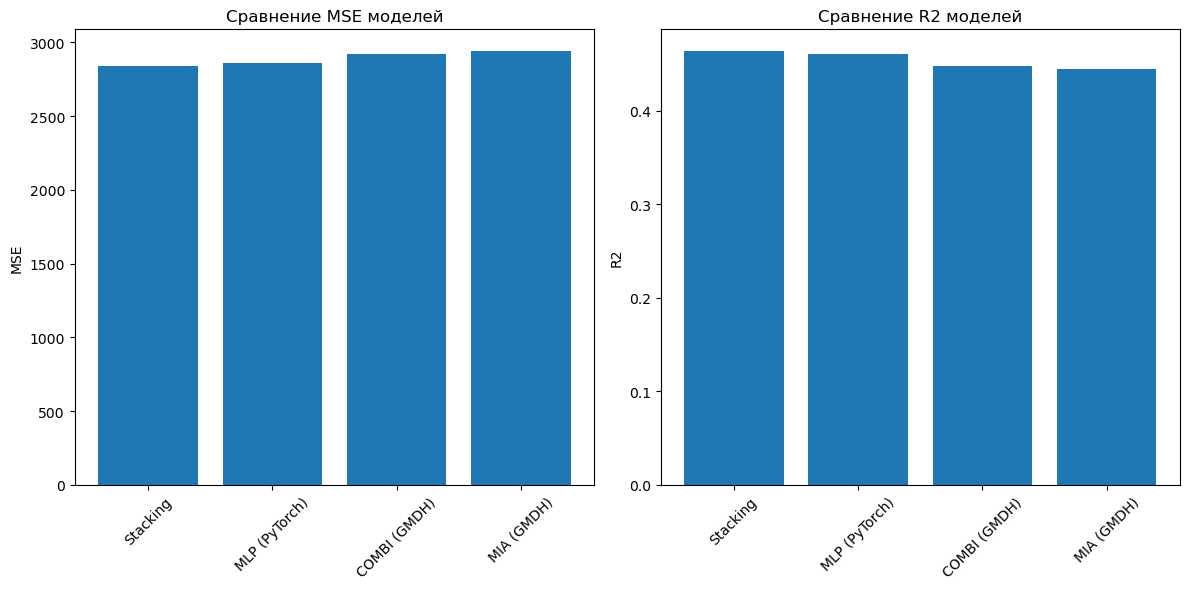

In [28]:
# Создание таблицы с результатами
results = pd.DataFrame({
    'Model': ['Stacking', 'MLP (PyTorch)', 'COMBI (GMDH)', 'MIA (GMDH)'],
    'MSE': [mse_stack, mse_mlp, mse_combi, mse_mia],
    'R2': [r2_stack, r2_mlp, r2_combi, r2_mia]
})

# Вывод результатов
print("\nСравнение моделей:")
display(results)

# Визуализация результатов
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(results['Model'], results['MSE'])
plt.title('Сравнение MSE моделей')
plt.xticks(rotation=45)
plt.ylabel('MSE')

plt.subplot(1, 2, 2)
plt.bar(results['Model'], results['R2'])
plt.title('Сравнение R2 моделей')
plt.xticks(rotation=45)
plt.ylabel('R2')

plt.tight_layout()
plt.show()